# Title : Analyzing Sales Performance by Region in a Retail Company

In [ ]:
sudo apt-get update
sudo apt-get install -y python3 python3-pip python3-venv libfreetype6-dev libx11-dev libpng-dev

pip install notebook==6.5.4
pip install pandas==1.5.3
pip install matplotlib==3.7.1


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("customer_shopping_data.csv") 
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [3]:
df.tail()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
99452,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,21/09/2022,Kanyon
99453,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,22/09/2021,Forum Istanbul
99454,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,28/03/2021,Metrocity
99455,I702964,C800631,Male,56,Technology,4,4200.00,Cash,16/03/2021,Istinye Park
99456,I232867,C273973,Female,36,Souvenir,3,35.19,Credit Card,15/10/2022,Mall of Istanbul


In [4]:
# To check the count of records grouped by region/branch of the mall
df.groupby("shopping_mall").count()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date
shopping_mall,,,,,,,,,
Cevahir AVM,4991,4991,4991,4991,4991,4991,4991,4991,4991
Emaar Square Mall,4811,4811,4811,4811,4811,4811,4811,4811,4811
Forum Istanbul,4947,4947,4947,4947,4947,4947,4947,4947,4947
Istinye Park,9781,9781,9781,9781,9781,9781,9781,9781,9781
Kanyon,19823,19823,19823,19823,19823,19823,19823,19823,19823
Mall of Istanbul,19943,19943,19943,19943,19943,19943,19943,19943,19943
Metrocity,15011,15011,15011,15011,15011,15011,15011,15011,15011
Metropol AVM,10161,10161,10161,10161,10161,10161,10161,10161,10161
Viaport Outlet,4914,4914,4914,4914,4914,4914,4914,4914,4914


In [5]:
# To check the count of records grouped by the product categories
df.groupby("category").count()

,invoice_no,customer_id,gender,age,quantity,price,payment_method,invoice_date,shopping_mall
category,,,,,,,,,
Books,4981,4981,4981,4981,4981,4981,4981,4981,4981
Clothing,34487,34487,34487,34487,34487,34487,34487,34487,34487
Cosmetics,15097,15097,15097,15097,15097,15097,15097,15097,15097
Food & Beverage,14776,14776,14776,14776,14776,14776,14776,14776,14776
Shoes,10034,10034,10034,10034,10034,10034,10034,10034,10034
Souvenir,4999,4999,4999,4999,4999,4999,4999,4999,4999
Technology,4996,4996,4996,4996,4996,4996,4996,4996,4996
Toys,10087,10087,10087,10087,10087,10087,10087,10087,10087


In [6]:
# total sales for each mall branch
branch_sales = df.groupby("shopping_mall").sum(numeric_only=True)
branch_sales

,age,quantity,price
shopping_mall,,,
Cevahir AVM,215474,14949,3433671.84
Emaar Square Mall,209575,14501,3390408.31
Forum Istanbul,215380,14852,3336073.82
Istinye Park,424335,29465,6717077.54
Kanyon,862280,59457,13710755.24
Mall of Istanbul,866333,60114,13851737.62
Metrocity,652968,44894,10249980.07
Metropol AVM,439086,30530,6937992.99
Viaport Outlet,212771,14716,3414019.46


In [15]:
# total sales for each category of product ("category")[['quantity', 'price']]



category_sales = df.groupby("category")[['quantity', 'price']].sum()
print(category_sales)


                 quantity        price
category                              
Books               14982    226977.30
Clothing           103558  31075684.64
Cosmetics           45465   1848606.90
Food & Beverage     44277    231568.71
Shoes               30217  18135336.89
Souvenir            14871    174436.83
Technology          15021  15772050.00
Toys                30321   1086704.64


In [16]:
# to get the top performing branches
branch_sales.sort_values(by = "price", ascending = False)

,age,quantity,price
shopping_mall,,,
Mall of Istanbul,866333,60114,13851737.62
Kanyon,862280,59457,13710755.24
Metrocity,652968,44894,10249980.07
Metropol AVM,439086,30530,6937992.99
Istinye Park,424335,29465,6717077.54
Zorlu Center,220926,15234,3509649.02
Cevahir AVM,215474,14949,3433671.84
Viaport Outlet,212771,14716,3414019.46
Emaar Square Mall,209575,14501,3390408.31


In [17]:
# to get the top selling categories
category_sales.sort_values(by = "price", ascending = False)

,quantity,price
category,,
Clothing,103558,31075684.64
Shoes,30217,18135336.89
Technology,15021,15772050.00
Cosmetics,45465,1848606.90
Toys,30321,1086704.64
Food & Beverage,44277,231568.71
Books,14982,226977.30
Souvenir,14871,174436.83


In [18]:
# to get total sales for each combination of branch and product_category
combined_branch_category_sales = df.groupby(["shopping_mall", "category"]).sum(numeric_only=True)
combined_branch_category_sales

age  quantity       price
shopping_mall category                                    
Cevahir AVM   Books            11464       792    11998.80
              Clothing         74729      5180  1554414.40
              Cosmetics        31142      2174    88394.84
              Food & Beverage  33269      2293    11992.39
              Shoes            21211      1473   884050.41
...                              ...       ...         ...
Zorlu Center  Food & Beverage  32687      2216    11589.68
              Shoes            22949      1589   953670.13
              Souvenir         10727       716     8398.68
              Technology       10533       765   803250.00
              Toys             22395      1526    54691.84

[80 rows x 3 columns]

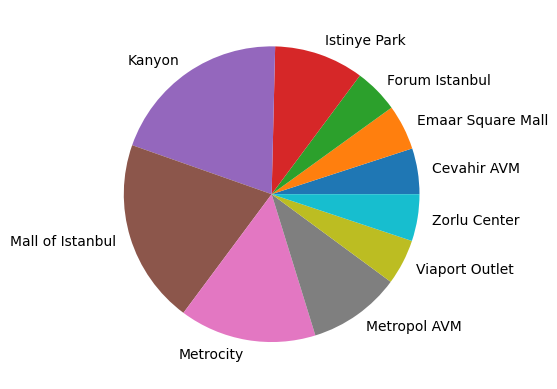

In [19]:
# pie chart for sales by branch
plt.pie(branch_sales["price"], labels = branch_sales.index) 
plt.show()

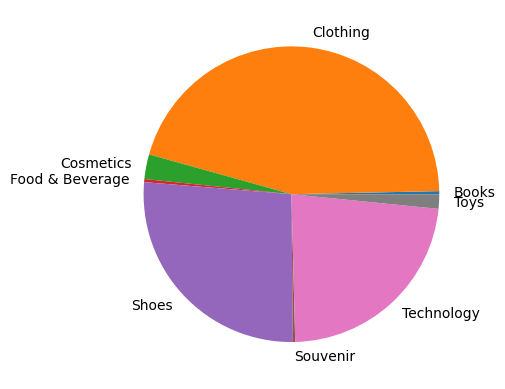

In [20]:
# pie chart for sales by product category
plt.pie(category_sales["price"], labels = category_sales.index) 
plt.show()

In [13]:
combined_pivot = df.pivot_table(index="shopping_mall", columns="category", values="price", aggfunc="sum") 

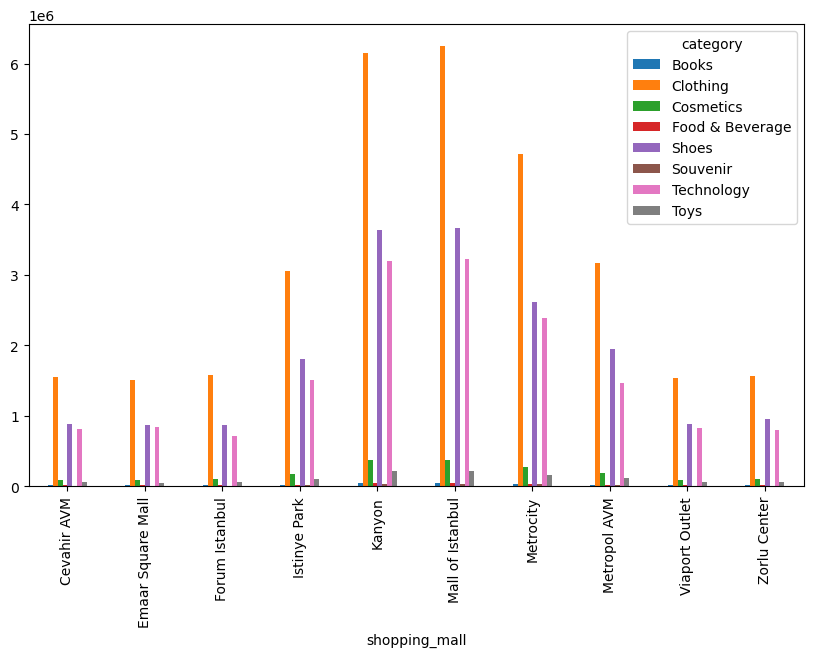

In [14]:
# grouped bar chart for sales of different categories at different branches
combined_pivot.plot(kind="bar", figsize=(10, 6)) 
plt.show()